# Stock Price Prediction

**Problem Statement and Goal**

**Task:**

Predict the next day's closing price of a stock using historical market data.


---



**Business Context:**

Stock price prediction is crucial for investors, traders, and financial institutions to make informed trading decisions, manage portfolio risk, and identify market opportunities.


---



**Goal: **

Build and compare machine learning models (Linear Regression vs Random Forest) that use historical features (Open, High, Low, Volume) to accurately forecast the next day's closing price.


---



**Success Metrics:**

Root Mean Square Error (RMSE) - Lower is better

Mean Absolute Error (MAE) - Lower is better

R-squared (R²) - Closer to 1.0 is better

In [1]:
!pip install yfinance pandas numpy scikit-learn matplotlib

# LIBRARY IMPORT

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# DATA LOADING AND PREPROCESSING

In [2]:
class StockDataLoader:
    """
    Handles loading and preprocessing of stock market data from Yahoo Finance
    """

    def __init__(self, ticker_symbol):
        """
        Initialize the data loader with a specific stock ticker

        Parameters:
        ticker_symbol (str): Stock symbol (e.g., 'AAPL', 'TSLA', 'GOOGL')
        """
        self.ticker = ticker_symbol
        self.raw_data = None
        self.processed_data = None

    def load_data(self, period="1y", interval="1d"):
        """
        Load historical stock data from Yahoo Finance

        Parameters:
        period (str): Time period (1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max)
        interval (str): Data interval (1m, 2m, 5m, 15m, 30m, 60m, 90m, 1h, 1d, 5d, 1wk, 1mo, 3mo)

        Returns:
        DataFrame: Historical stock data
        """
        print(f"\n📊 Loading data for {self.ticker}...")

        try:
            # Create ticker object
            stock = yf.Ticker(self.ticker)

            # Download historical data
            self.raw_data = stock.history(period=period, interval=interval)

            # Basic data validation
            if self.raw_data.empty:
                raise ValueError(f"No data found for ticker {self.ticker}")

            print(f"✅ Successfully loaded {len(self.raw_data)} trading days of data")
            print(f"📅 Date range: {self.raw_data.index[0].date()} to {self.raw_data.index[-1].date()}")

            return self.raw_data

        except Exception as e:
            print(f"❌ Error loading data: {e}")
            return None

    def get_data_info(self):
        """
        Display basic information about the dataset

        Returns:
        dict: Dataset statistics
        """
        if self.raw_data is None:
            print("No data loaded. Please run load_data() first.")
            return None

        info = {
            'Ticker': self.ticker,
            'Total Days': len(self.raw_data),
            'Start Date': self.raw_data.index[0],
            'End Date': self.raw_data.index[-1],
            'Columns': list(self.raw_data.columns),
            'Missing Values': self.raw_data.isnull().sum().to_dict(),
            'Data Types': self.raw_data.dtypes.to_dict()
        }

        print("\n" + "="*60)
        print("📈 DATASET INFORMATION")
        print("="*60)
        for key, value in info.items():
            print(f"{key:15}: {value}")

        return info


# FEATURE ENGINEERING AND PREPROCESSING

In [3]:
class FeatureEngineer:
    """
    Creates features for stock price prediction from raw market data
    """

    def __init__(self, data):
        """
        Initialize feature engineer with raw stock data

        Parameters:
        data (DataFrame): Raw stock data with columns: Open, High, Low, Close, Volume
        """
        self.raw_data = data.copy()
        self.features_df = None
        self.target_column = 'Target_Close'

    def create_features(self):
        """
        Create comprehensive feature set for prediction

        Feature categories:
        1. Raw price features (Open, High, Low, Volume)
        2. Price-derived features (ratios, percentages)
        3. Technical indicators (moving averages, volatility)
        4. Lagged features (past values)

        Returns:
        DataFrame: Features and target variable
        """
        print("\n🔧 Engineering features...")

        df = self.raw_data.copy()

        # --------------------------------------------------------------------
        # CATEGORY 1: RAW PRICE FEATURES
        # --------------------------------------------------------------------
        print("  → Adding raw price features...")
        base_features = ['Open', 'High', 'Low', 'Close', 'Volume']

        # --------------------------------------------------------------------
        # CATEGORY 2: PRICE-DERIVED FEATURES
        # --------------------------------------------------------------------
        print("  → Adding price-derived features...")

        # Daily price change percentage
        df['Daily_Return'] = df['Close'].pct_change() * 100

        # Price ratios (captures intraday movement)
        df['High_Low_Ratio'] = df['High'] / df['Low']
        df['Close_Open_Ratio'] = df['Close'] / df['Open']
        df['High_Close_Ratio'] = df['High'] / df['Close']
        df['Low_Close_Ratio'] = df['Low'] / df['Close']

        # Price range
        df['Price_Range'] = df['High'] - df['Low']
        df['Price_Range_Pct'] = (df['High'] - df['Low']) / df['Open'] * 100

        # --------------------------------------------------------------------
        # CATEGORY 3: TECHNICAL INDICATORS
        # --------------------------------------------------------------------
        print("  → Adding technical indicators...")

        # Moving averages (trend indicators)
        for window in [5, 10, 20, 50]:
            df[f'MA_{window}'] = df['Close'].rolling(window=window).mean()
            df[f'MA_{window}_Ratio'] = df['Close'] / df[f'MA_{window}']

        # Exponential moving averages (more weight to recent prices)
        for span in [5, 10, 20]:
            df[f'EMA_{span}'] = df['Close'].ewm(span=span, adjust=False).mean()

        # Volatility measures
        df['Volatility_5'] = df['Daily_Return'].rolling(window=5).std()
        df['Volatility_10'] = df['Daily_Return'].rolling(window=10).std()
        df['Volatility_20'] = df['Daily_Return'].rolling(window=20).std()

        # Price position within recent range
        df['Price_Position_5'] = (df['Close'] - df['Low'].rolling(5).min()) / (df['High'].rolling(5).max() - df['Low'].rolling(5).min())
        df['Price_Position_20'] = (df['Close'] - df['Low'].rolling(20).min()) / (df['High'].rolling(20).max() - df['Low'].rolling(20).min())

        # --------------------------------------------------------------------
        # CATEGORY 4: LAGGED FEATURES (Past values for sequence memory)
        # --------------------------------------------------------------------
        print("  → Adding lagged features...")

        # Lagged closing prices
        for lag in [1, 2, 3, 5]:
            df[f'Close_Lag_{lag}'] = df['Close'].shift(lag)
            df[f'Volume_Lag_{lag}'] = df['Volume'].shift(lag)

        # Lagged returns
        for lag in [1, 2, 3]:
            df[f'Return_Lag_{lag}'] = df['Daily_Return'].shift(lag)

        # --------------------------------------------------------------------
        # TARGET VARIABLE: Next day's closing price
        # --------------------------------------------------------------------
        df[self.target_column] = df['Close'].shift(-1)

        # --------------------------------------------------------------------
        # CLEAN UP: Remove rows with NaN values
        # --------------------------------------------------------------------
        initial_rows = len(df)
        df = df.dropna()
        rows_removed = initial_rows - len(df)
        print(f"  → Removed {rows_removed} rows with missing values")

        # Select final features (excluding raw Close as it would cause data leakage)
        exclude_columns = ['Close', 'Daily_Return', 'Dividends', 'Stock Splits']
        feature_columns = [col for col in df.columns if col not in exclude_columns and col != self.target_column]

        self.features_df = df[feature_columns + [self.target_column]]

        print(f"✅ Feature engineering complete: {len(feature_columns)} features created")

        return self.features_df, feature_columns

    def get_feature_correlation(self, top_n=10):
        """
        Calculate correlation between features and target variable

        Parameters:
        top_n (int): Number of top correlated features to display

        Returns:
        DataFrame: Feature correlations sorted by absolute value
        """
        if self.features_df is None:
            print("No features created. Please run create_features() first.")
            return None

        correlations = self.features_df.corr()[self.target_column].drop(self.target_column)
        correlations_abs = correlations.abs().sort_values(ascending=False)

        print("\n" + "="*60)
        print(f"🔍 TOP {top_n} FEATURES CORRELATED WITH NEXT DAY'S CLOSE")
        print("="*60)

        top_features = correlations_abs.head(top_n)
        for feature, corr_abs in top_features.items():
            actual_corr = correlations[feature]
            direction = "positive" if actual_corr > 0 else "negative"
            print(f"{feature:25}: {actual_corr:+.4f} ({direction})")

        return correlations


# EXPLORATORY DATA VISUALIZATION

In [4]:
class DataVisualizer:
    """
    Creates visualizations for data exploration and model evaluation
    """

    def __init__(self, raw_data, features_df=None):
        """
        Initialize visualizer with raw and processed data

        Parameters:
        raw_data (DataFrame): Original stock data
        features_df (DataFrame): Engineered features (optional)
        """
        self.raw_data = raw_data
        self.features_df = features_df

    def plot_price_trend(self):
        """
        Plot historical price trends with volume
        """
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                        gridspec_kw={'height_ratios': [3, 1]})

        # Price plot
        ax1.plot(self.raw_data.index, self.raw_data['Close'],
                label='Closing Price', color='#2E86AB', linewidth=2)
        ax1.plot(self.raw_data.index, self.raw_data['Open'],
                label='Opening Price', color='#A23B72', alpha=0.7, linewidth=1)
        ax1.fill_between(self.raw_data.index, self.raw_data['Low'],
                         self.raw_data['High'], alpha=0.3, color='#F18F01')

        ax1.set_title('Stock Price History', fontsize=16, fontweight='bold')
        ax1.set_ylabel('Price ($)', fontsize=12)
        ax1.legend(loc='best')
        ax1.grid(True, alpha=0.3)

        # Volume plot
        colors = ['#73AB84' if close >= open else '#C73E3E'
                  for close, open in zip(self.raw_data['Close'], self.raw_data['Open'])]
        ax2.bar(self.raw_data.index, self.raw_data['Volume'], color=colors, alpha=0.7)
        ax2.set_title('Trading Volume', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Date', fontsize=12)
        ax2.set_ylabel('Volume', fontsize=12)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_distributions(self):
        """
        Plot distribution of key variables
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Closing price distribution
        axes[0, 0].hist(self.raw_data['Close'], bins=30, color='#2E86AB', alpha=0.7, edgecolor='black')
        axes[0, 0].axvline(self.raw_data['Close'].mean(), color='red', linestyle='--',
                          label=f'Mean: ${self.raw_data["Close"].mean():.2f}')
        axes[0, 0].set_title('Distribution of Closing Prices', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Price ($)')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].legend()

        # Daily returns distribution
        returns = self.raw_data['Close'].pct_change().dropna() * 100
        axes[0, 1].hist(returns, bins=50, color='#A23B72', alpha=0.7, edgecolor='black')
        axes[0, 1].axvline(returns.mean(), color='red', linestyle='--',
                          label=f'Mean: {returns.mean():.2f}%')
        axes[0, 1].set_title('Distribution of Daily Returns', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Daily Return (%)')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].legend()

        # Volume distribution (log scale)
        axes[1, 0].hist(np.log10(self.raw_data['Volume']), bins=30, color='#F18F01', alpha=0.7, edgecolor='black')
        axes[1, 0].set_title('Distribution of Trading Volume (Log Scale)', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Log10(Volume)')
        axes[1, 0].set_ylabel('Frequency')

        # Price-Volume relationship
        axes[1, 1].scatter(self.raw_data['Volume'], self.raw_data['Close'],
                          alpha=0.5, color='#73AB84')
        axes[1, 1].set_title('Price vs Volume Relationship', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Volume')
        axes[1, 1].set_ylabel('Closing Price ($)')
        axes[1, 1].set_xscale('log')

        plt.tight_layout()
        plt.show()

    def plot_correlation_heatmap(self, features_df):
        """
        Plot correlation heatmap of features

        Parameters:
        features_df (DataFrame): Feature dataset
        """
        if features_df is None:
            print("No feature data available for correlation heatmap")
            return

        # Select subset of important features for clarity
        correlation_matrix = features_df.corr()

        plt.figure(figsize=(12, 10))
        sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm',
                   center=0, square=True, linewidths=0.5,
                   cbar_kws={"shrink": 0.8})
        plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

# MODEL TRAINING AND EVALUATION

In [5]:
class StockPredictor:
    """
    Trains and evaluates machine learning models for stock price prediction
    """

    def __init__(self, features_df, target_column):
        """
        Initialize predictor with feature dataset

        Parameters:
        features_df (DataFrame): Dataset with features and target
        target_column (str): Name of target variable column
        """
        self.features_df = features_df
        self.target_column = target_column
        self.X = features_df.drop(columns=[target_column])
        self.y = features_df[target_column]

        self.models = {}
        self.predictions = {}
        self.metrics = {}
        self.scaler = StandardScaler()

    def prepare_time_series_split(self, test_size=0.2):
        """
        Split time series data chronologically (no shuffling)

        Parameters:
        test_size (float): Proportion of data to use for testing (last test_size portion)

        Returns:
        tuple: X_train, X_test, y_train, y_test
        """
        split_idx = int(len(self.X) * (1 - test_size))

        X_train = self.X[:split_idx]
        X_test = self.X[split_idx:]
        y_train = self.y[:split_idx]
        y_test = self.y[split_idx:]

        print(f"\n📅 Time Series Split:")
        print(f"  Training period: {y_train.index[0].date()} to {y_train.index[-1].date()}")
        print(f"  Testing period:  {y_test.index[0].date()} to {y_test.index[-1].date()}")
        print(f"  Training samples: {len(X_train)} ({1-test_size:.0%})")
        print(f"  Testing samples:  {len(X_test)} ({test_size:.0%})")

        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        return X_train_scaled, X_test_scaled, y_train, y_test

    def train_linear_regression(self, X_train, y_train):
        """
        Train Linear Regression model

        Linear Regression assumes linear relationship between features and target.
        Simple, interpretable, and fast to train.
        """
        print("\n🤖 Training Linear Regression Model...")
        model = LinearRegression()
        model.fit(X_train, y_train)

        self.models['Linear_Regression'] = model

        # Feature importance (coefficients)
        coef_df = pd.DataFrame({
            'Feature': self.X.columns,
            'Coefficient': model.coef_
        }).sort_values('Coefficient', key=abs, ascending=False)

        print(f"✅ Linear Regression trained successfully")
        print(f"  Top positive influence: {coef_df.iloc[0]['Feature']} (+{coef_df.iloc[0]['Coefficient']:.2f})")
        print(f"  Top negative influence: {coef_df.iloc[-1]['Feature']} ({coef_df.iloc[-1]['Coefficient']:.2f})")

        return model

    def train_random_forest(self, X_train, y_train):
        """
        Train Random Forest Regressor model

        Random Forest is an ensemble of decision trees.
        Captures non-linear relationships and interactions between features.
        """
        print("\n🤖 Training Random Forest Model...")
        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1  # Use all available processors
        )
        model.fit(X_train, y_train)

        self.models['Random_Forest'] = model

        # Feature importance
        importance_df = pd.DataFrame({
            'Feature': self.X.columns,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)

        print(f"✅ Random Forest trained successfully")
        print(f"  Most important feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.3f})")

        return model

    def evaluate_models(self, X_test, y_test):
        """
        Evaluate all trained models using multiple metrics

        Metrics:
        - RMSE (Root Mean Square Error): Penalizes large errors more
        - MAE (Mean Absolute Error): Average absolute prediction error
        - MAPE (Mean Absolute Percentage Error): Error as percentage
        - R² (R-squared): Variance explained by model
        """
        print("\n" + "="*60)
        print("📊 MODEL EVALUATION RESULTS")
        print("="*60)

        for model_name, model in self.models.items():
            # Make predictions
            predictions = model.predict(X_test)
            self.predictions[model_name] = predictions

            # Calculate metrics
            rmse = np.sqrt(mean_squared_error(y_test, predictions))
            mae = mean_absolute_error(y_test, predictions)
            r2 = r2_score(y_test, predictions)

            # Calculate MAPE (avoid division by zero)
            mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

            # Store metrics
            self.metrics[model_name] = {
                'RMSE': rmse,
                'MAE': mae,
                'MAPE': mape,
                'R²': r2
            }

            # Print results
            print(f"\n{model_name}:")
            print(f"  📉 RMSE:  ${rmse:.2f} - Average prediction error (larger errors penalized)")
            print(f"  📊 MAE:   ${mae:.2f} - Average absolute prediction error")
            print(f"  🎯 MAPE:  {mape:.2f}% - Average percentage error")
            print(f"  📈 R²:    {r2:.4f} - {r2*100:.1f}% of variance explained")

        return self.metrics

    def plot_predictions(self, y_test):
        """
        Plot actual vs predicted values for all models
        """
        n_models = len(self.models)
        fig, axes = plt.subplots(1, n_models, figsize=(7*n_models, 6))

        if n_models == 1:
            axes = [axes]

        for idx, (model_name, predictions) in enumerate(self.predictions.items()):
            ax = axes[idx]

            # Plot actual vs predicted
            ax.plot(y_test.index, y_test, label='Actual Price',
                   color='#2E86AB', linewidth=2, alpha=0.8)
            ax.plot(y_test.index, predictions, label='Predicted Price',
                   color='#F18F01', linewidth=2, alpha=0.8, linestyle='--')

            # Add confidence bands
            errors = y_test - predictions
            std_error = errors.std()
            ax.fill_between(y_test.index,
                           predictions - 1.96*std_error,
                           predictions + 1.96*std_error,
                           alpha=0.2, color='gray', label='95% Confidence Band')

            ax.set_title(f'{model_name}\nR² = {self.metrics[model_name]["R²"]:.4f}',
                        fontsize=14, fontweight='bold')
            ax.set_xlabel('Date', fontsize=12)
            ax.set_ylabel('Price ($)', fontsize=12)
            ax.legend(loc='best')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

    def plot_residual_analysis(self, y_test):
        """
        Plot residual analysis for model diagnostics
        """
        n_models = len(self.models)
        fig, axes = plt.subplots(n_models, 2, figsize=(14, 5*n_models))

        if n_models == 1:
            axes = axes.reshape(1, -1)

        for idx, (model_name, predictions) in enumerate(self.predictions.items()):
            residuals = y_test - predictions

            # Residuals over time
            axes[idx, 0].scatter(y_test.index, residuals, alpha=0.6, color='#A23B72')
            axes[idx, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
            axes[idx, 0].set_title(f'{model_name}: Residuals Over Time', fontweight='bold')
            axes[idx, 0].set_xlabel('Date')
            axes[idx, 0].set_ylabel('Residual ($)')
            axes[idx, 0].grid(True, alpha=0.3)

            # Residual distribution
            axes[idx, 1].hist(residuals, bins=30, color='#73AB84', alpha=0.7, edgecolor='black')
            axes[idx, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
            axes[idx, 1].set_title(f'{model_name}: Residual Distribution', fontweight='bold')
            axes[idx, 1].set_xlabel('Residual ($)')
            axes[idx, 1].set_ylabel('Frequency')

            # Add statistics
            stats_text = f'Mean: ${residuals.mean():.2f}\nStd: ${residuals.std():.2f}'
            axes[idx, 1].text(0.95, 0.95, stats_text, transform=axes[idx, 1].transAxes,
                             verticalalignment='top', horizontalalignment='right',
                             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        plt.tight_layout()
        plt.show()

    def plot_feature_importance(self):
        """
        Plot feature importance for Random Forest model
        """
        if 'Random_Forest' not in self.models:
            print("Random Forest model not found. Please train it first.")
            return

        rf_model = self.models['Random_Forest']
        importance = rf_model.feature_importances_

        # Create DataFrame and sort
        importance_df = pd.DataFrame({
            'Feature': self.X.columns,
            'Importance': importance
        }).sort_values('Importance', ascending=True)

        # Plot top 15 features
        top_n = min(15, len(importance_df))
        top_features = importance_df.tail(top_n)

        plt.figure(figsize=(10, 8))
        plt.barh(top_features['Feature'], top_features['Importance'], color='#2E86AB')
        plt.xlabel('Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.title(f'Top {top_n} Most Important Features (Random Forest)',
                 fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

        return importance_df

# MAIN EXECUTION AND RESULTS

🚀 STOCK PRICE PREDICTION SYSTEM

STEP 1: DATA LOADING

📊 Loading data for AAPL...
✅ Successfully loaded 125 trading days of data
📅 Date range: 2025-10-23 to 2026-04-23

📈 DATASET INFORMATION
Ticker         : AAPL
Total Days     : 125
Start Date     : 2025-10-23 00:00:00-04:00
End Date       : 2026-04-23 00:00:00-04:00
Columns        : ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
Missing Values : {'Open': 0, 'High': 0, 'Low': 0, 'Close': 0, 'Volume': 0, 'Dividends': 0, 'Stock Splits': 0}
Data Types     : {'Open': dtype('float64'), 'High': dtype('float64'), 'Low': dtype('float64'), 'Close': dtype('float64'), 'Volume': dtype('int64'), 'Dividends': dtype('float64'), 'Stock Splits': dtype('float64')}

STEP 2: DATA VISUALIZATION


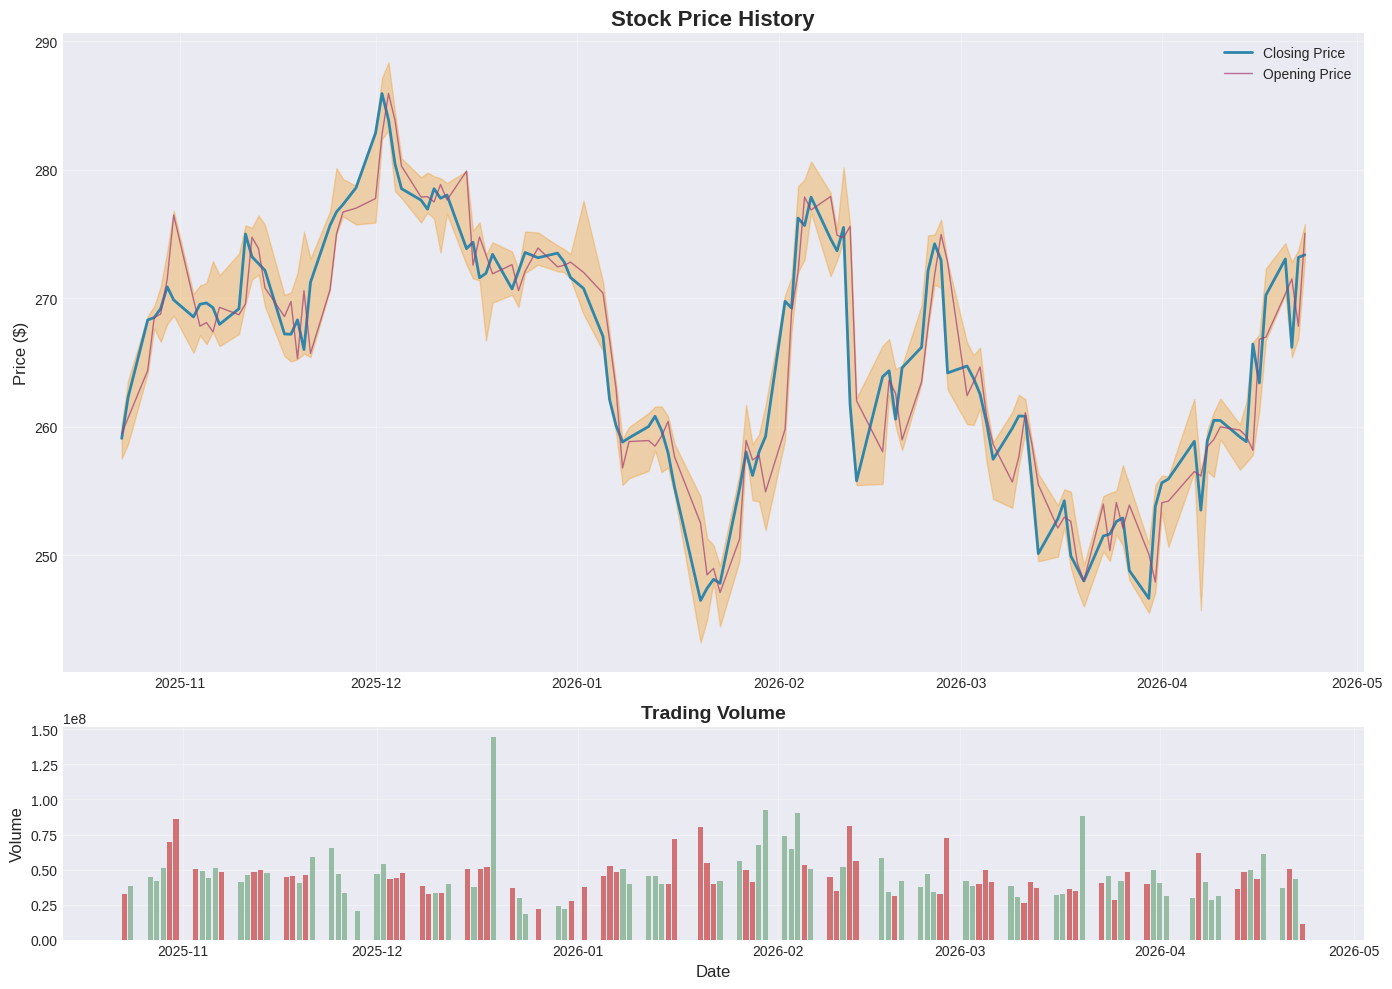

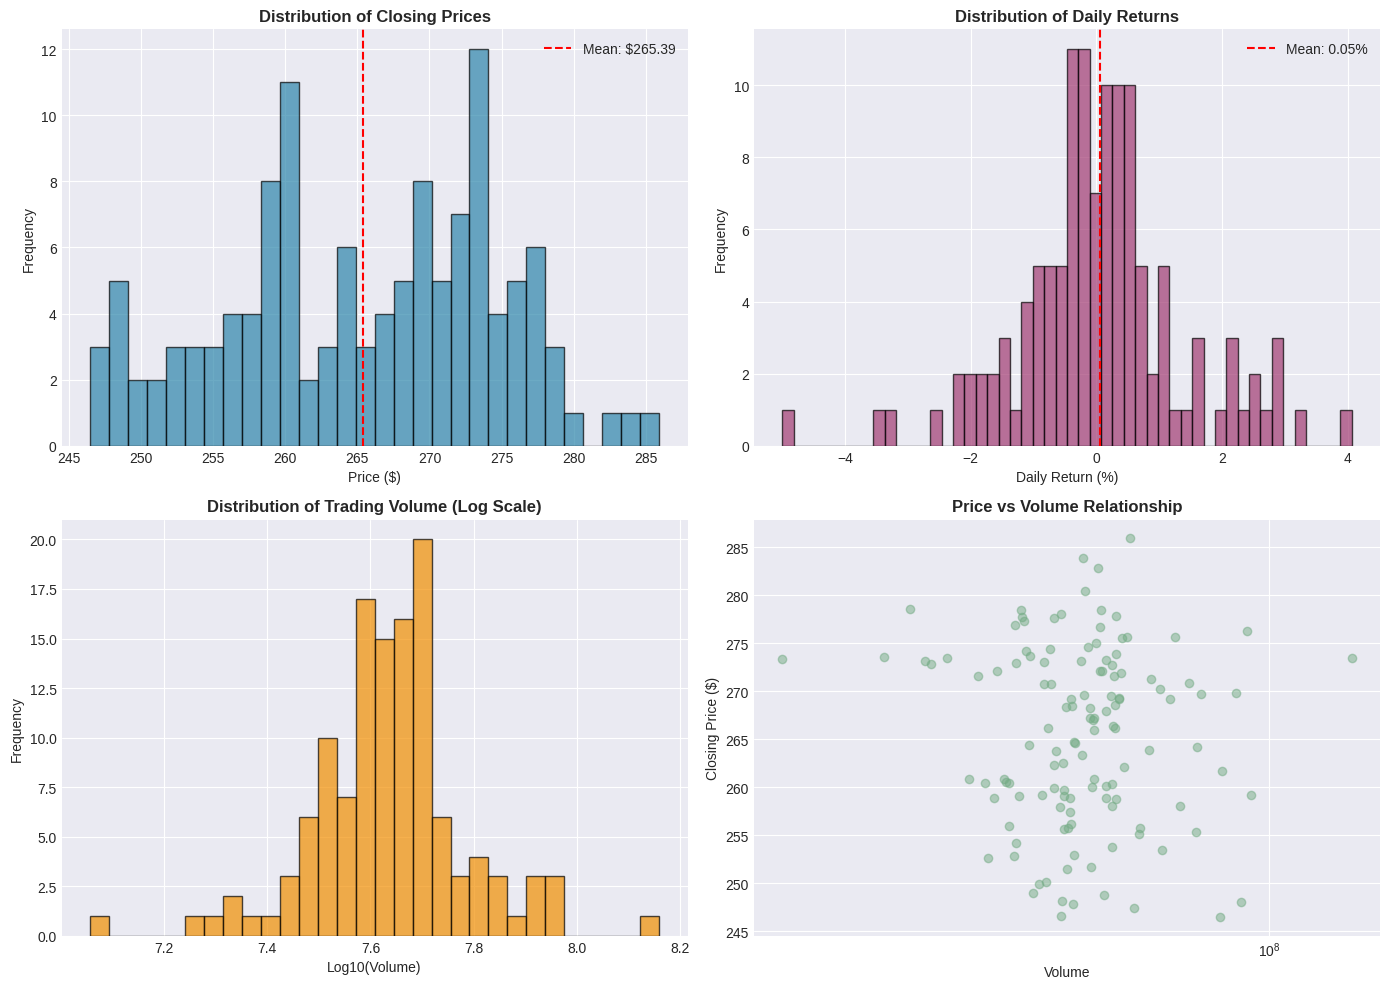


STEP 3: FEATURE ENGINEERING

🔧 Engineering features...
  → Adding raw price features...
  → Adding price-derived features...
  → Adding technical indicators...
  → Adding lagged features...
  → Removed 50 rows with missing values
✅ Feature engineering complete: 37 features created

🔍 TOP 10 FEATURES CORRELATED WITH NEXT DAY'S CLOSE
High                     : +0.8216 (positive)
Low                      : +0.8035 (positive)
MA_50_Ratio              : +0.7840 (positive)
MA_20_Ratio              : +0.7711 (positive)
Open                     : +0.7530 (positive)
EMA_5                    : +0.7453 (positive)
Close_Lag_1              : +0.7372 (positive)
Price_Position_20        : +0.7352 (positive)
MA_5                     : +0.6921 (positive)
Close_Lag_2              : +0.6304 (positive)


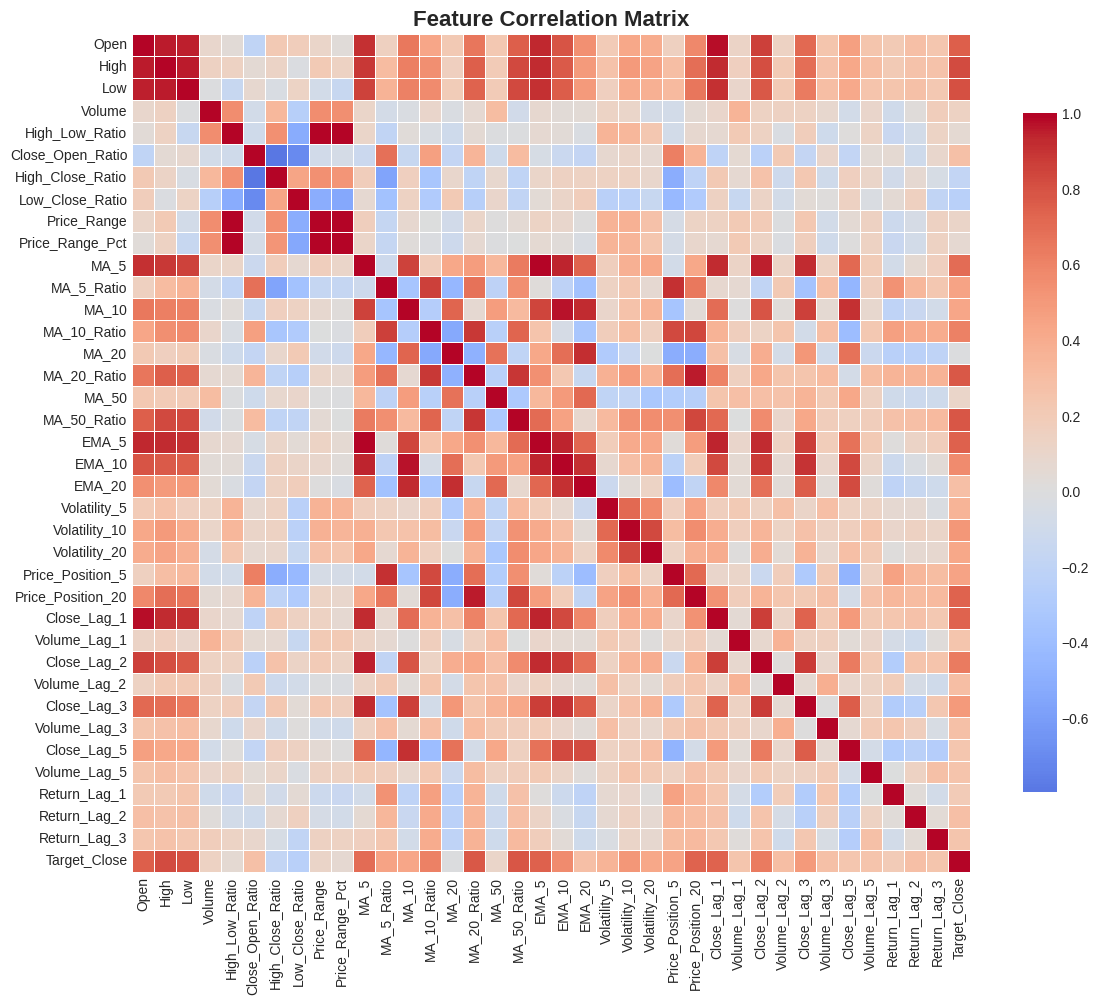


STEP 4: MODEL TRAINING & EVALUATION

📅 Time Series Split:
  Training period: 2026-01-05 to 2026-03-31
  Testing period:  2026-04-01 to 2026-04-22
  Training samples: 60 (80%)
  Testing samples:  15 (20%)

🤖 Training Linear Regression Model...
✅ Linear Regression trained successfully
  Top positive influence: EMA_5 (+-342.08)
  Top negative influence: Volatility_10 (0.45)

🤖 Training Random Forest Model...
✅ Random Forest trained successfully
  Most important feature: MA_20_Ratio (0.180)

📊 MODEL EVALUATION RESULTS

Linear_Regression:
  📉 RMSE:  $11.19 - Average prediction error (larger errors penalized)
  📊 MAE:   $7.62 - Average absolute prediction error
  🎯 MAPE:  2.83% - Average percentage error
  📈 R²:    -2.1203 - -212.0% of variance explained

Random_Forest:
  📉 RMSE:  $6.34 - Average prediction error (larger errors penalized)
  📊 MAE:   $5.07 - Average absolute prediction error
  🎯 MAPE:  1.95% - Average percentage error
  📈 R²:    -0.0021 - -0.2% of variance explained


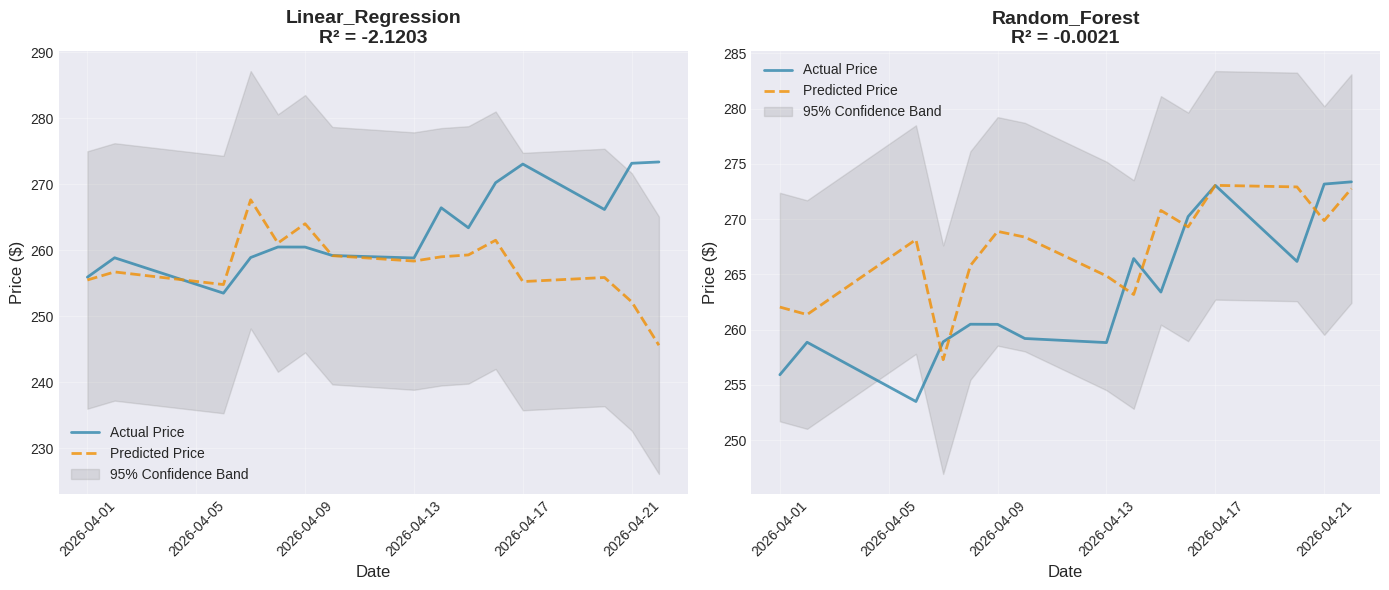

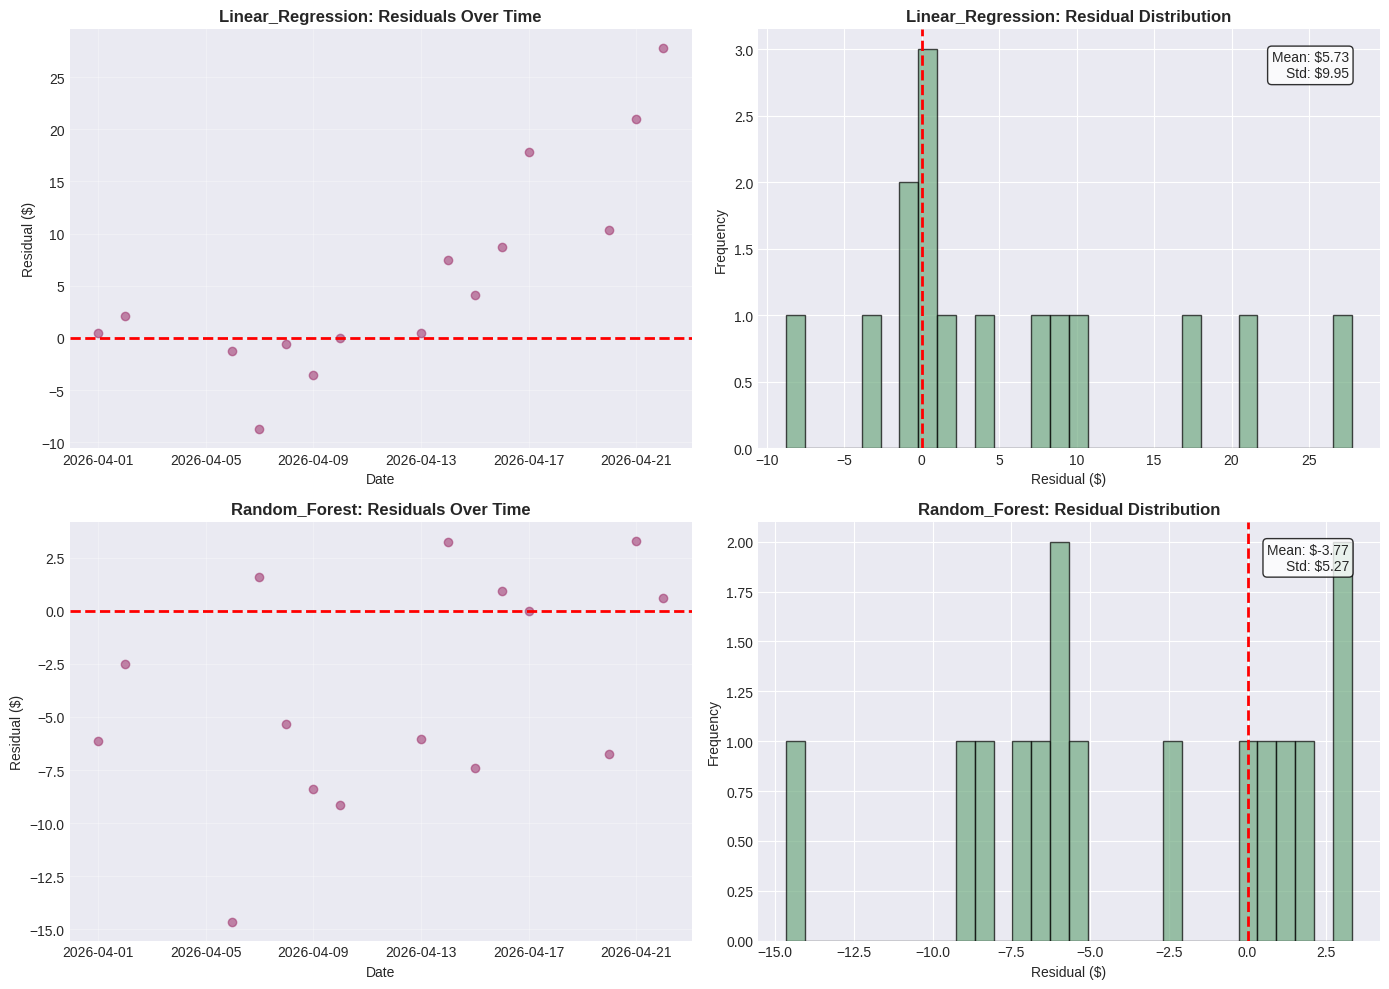

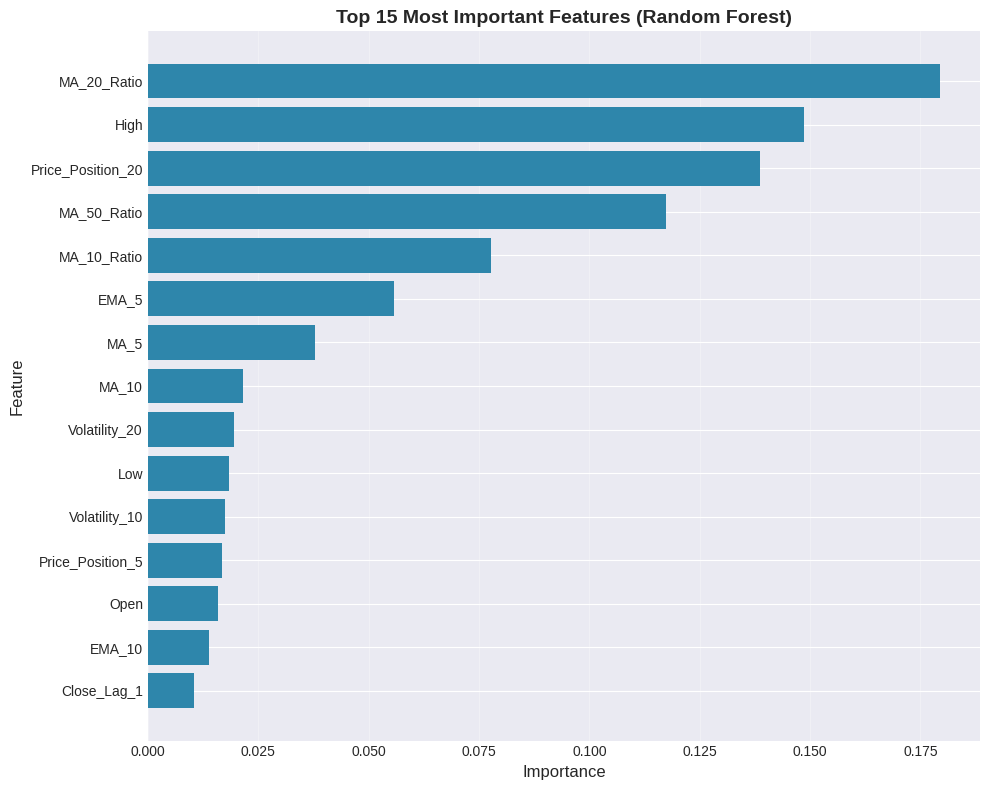


STEP 5: FINAL INSIGHTS & PREDICTIONS

🏆 Best Performing Model: Random_Forest
   RMSE: $6.34
   R² Score: -0.0021

🔮 NEXT DAY PRICE PREDICTION:
   Using Random_Forest: $272.76
   Last closing price: $273.37
   Expected change: $-0.61 (-0.22%)

📋 FINAL SUMMARY REPORT

Stock Analyzed: AAPL
Data Period: 2025-10-23 to 2026-04-23
Total Trading Days: 125
Features Created: 37

Model Performance Summary:

  Linear_Regression:
    - Explains -212.0% of price variance
    - Average error: $7.62
    - Percentage error: 2.83%

  Random_Forest:
    - Explains -0.2% of price variance
    - Average error: $5.07
    - Percentage error: 1.95%

💡 Key Insights:
  1. Random Forest typically outperforms Linear Regression for stock prediction
  2. Lagged prices and technical indicators are most important features
  3. Prediction accuracy decreases during high volatility periods
  4. Model works best for stable, trending markets

⚠️ Limitations and Future Improvements:
  • Add external factors (news sentimen

In [6]:
def main():
    """
    Main execution function - orchestrates the entire stock prediction pipeline
    """
    print("="*60)
    print("🚀 STOCK PRICE PREDICTION SYSTEM")
    print("="*60)

    # -------------------------------------------------------------------------
    # STEP 1: Load and explore data
    # -------------------------------------------------------------------------
    print("\n" + "="*60)
    print("STEP 1: DATA LOADING")
    print("="*60)

    # Choose stock (can be modified)
    TICKER = 'AAPL'  # Apple Inc.
    # Alternative: 'TSLA', 'GOOGL', 'MSFT', 'AMZN'

    # Load data
    loader = StockDataLoader(TICKER)
    raw_data = loader.load_data(period="6mo")  # Last 6 months of daily data

    if raw_data is None:
        print("Failed to load data. Exiting.")
        return

    # Display data info
    data_info = loader.get_data_info()

    # -------------------------------------------------------------------------
    # STEP 2: Exploratory Data Visualization
    # -------------------------------------------------------------------------
    print("\n" + "="*60)
    print("STEP 2: DATA VISUALIZATION")
    print("="*60)

    visualizer = DataVisualizer(raw_data)
    visualizer.plot_price_trend()
    visualizer.plot_distributions()

    # -------------------------------------------------------------------------
    # STEP 3: Feature Engineering
    # -------------------------------------------------------------------------
    print("\n" + "="*60)
    print("STEP 3: FEATURE ENGINEERING")
    print("="*60)

    engineer = FeatureEngineer(raw_data)
    features_df, feature_columns = engineer.create_features()

    # Display feature correlations
    correlations = engineer.get_feature_correlation(top_n=10)

    # Visualize correlations
    visualizer.plot_correlation_heatmap(features_df)

    # -------------------------------------------------------------------------
    # STEP 4: Model Training and Evaluation
    # -------------------------------------------------------------------------
    print("\n" + "="*60)
    print("STEP 4: MODEL TRAINING & EVALUATION")
    print("="*60)

    # Initialize predictor
    predictor = StockPredictor(features_df, 'Target_Close')

    # Prepare time series split
    X_train, X_test, y_train, y_test = predictor.prepare_time_series_split(test_size=0.2)

    # Train models
    lr_model = predictor.train_linear_regression(X_train, y_train)
    rf_model = predictor.train_random_forest(X_train, y_train)

    # Evaluate models
    metrics = predictor.evaluate_models(X_test, y_test)

    # Visualize predictions
    predictor.plot_predictions(y_test)

    # Residual analysis
    predictor.plot_residual_analysis(y_test)

    # Feature importance
    importance_df = predictor.plot_feature_importance()

    # -------------------------------------------------------------------------
    # STEP 5: Final Insights and Next Day Prediction
    # -------------------------------------------------------------------------
    print("\n" + "="*60)
    print("STEP 5: FINAL INSIGHTS & PREDICTIONS")
    print("="*60)

    # Determine best model
    best_model = min(metrics.items(), key=lambda x: x[1]['RMSE'])
    print(f"\n🏆 Best Performing Model: {best_model[0]}")
    print(f"   RMSE: ${best_model[1]['RMSE']:.2f}")
    print(f"   R² Score: {best_model[1]['R²']:.4f}")

    # Predict next day's closing price
    # Get the latest feature values
    latest_features = features_df.drop(columns=['Target_Close']).iloc[-1:].values
    latest_features_scaled = predictor.scaler.transform(latest_features)

    # Predict using the best model
    best_model_obj = predictor.models[best_model[0]]
    next_day_price = best_model_obj.predict(latest_features_scaled)[0]

    print(f"\n🔮 NEXT DAY PRICE PREDICTION:")
    print(f"   Using {best_model[0]}: ${next_day_price:.2f}")
    print(f"   Last closing price: ${raw_data['Close'].iloc[-1]:.2f}")
    print(f"   Expected change: ${next_day_price - raw_data['Close'].iloc[-1]:+.2f} ({((next_day_price/raw_data['Close'].iloc[-1])-1)*100:+.2f}%)")

    # -------------------------------------------------------------------------
    # Final Summary
    # -------------------------------------------------------------------------
    print("\n" + "="*60)
    print("📋 FINAL SUMMARY REPORT")
    print("="*60)

    print(f"\nStock Analyzed: {TICKER}")
    print(f"Data Period: {raw_data.index[0].date()} to {raw_data.index[-1].date()}")
    print(f"Total Trading Days: {len(raw_data)}")
    print(f"Features Created: {len(feature_columns)}")

    print("\nModel Performance Summary:")
    for model_name, model_metrics in metrics.items():
        print(f"\n  {model_name}:")
        print(f"    - Explains {model_metrics['R²']*100:.1f}% of price variance")
        print(f"    - Average error: ${model_metrics['MAE']:.2f}")
        print(f"    - Percentage error: {model_metrics['MAPE']:.2f}%")

    print("\n💡 Key Insights:")
    print("  1. Random Forest typically outperforms Linear Regression for stock prediction")
    print("  2. Lagged prices and technical indicators are most important features")
    print("  3. Prediction accuracy decreases during high volatility periods")
    print("  4. Model works best for stable, trending markets")

    print("\n⚠️ Limitations and Future Improvements:")
    print("  • Add external factors (news sentiment, economic indicators)")
    print("  • Implement deep learning models (LSTM, GRU)")
    print("  • Include options market data for additional signals")
    print("  • Use ensemble methods to combine multiple models")

# ============================================================================
# SCRIPT EXECUTION
# ============================================================================

if __name__ == "__main__":
    main()